# 03 — Hypothesis Testing

Test pre-registered hypotheses from EXPERIMENT.md:
- H1: Procedure adoption explains the admission surge
- H2: Geographic access gap drives patient migration

Controlled comparisons and statistical tests.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)

OUTPUT_DIR = Path("../outputs")
PLOT_DIR = OUTPUT_DIR / "plots"
METRICS_DIR = OUTPUT_DIR / "metrics"

kidney = pd.read_parquet(OUTPUT_DIR / "kidney_sih.parquet")
print(f"Loaded {len(kidney):,} records")

Loaded 206,500 records


## H1: Procedure Decomposition

How much of the admission growth is explained by the new ureterolithotripsy procedure (0409010596) vs. legacy procedures?

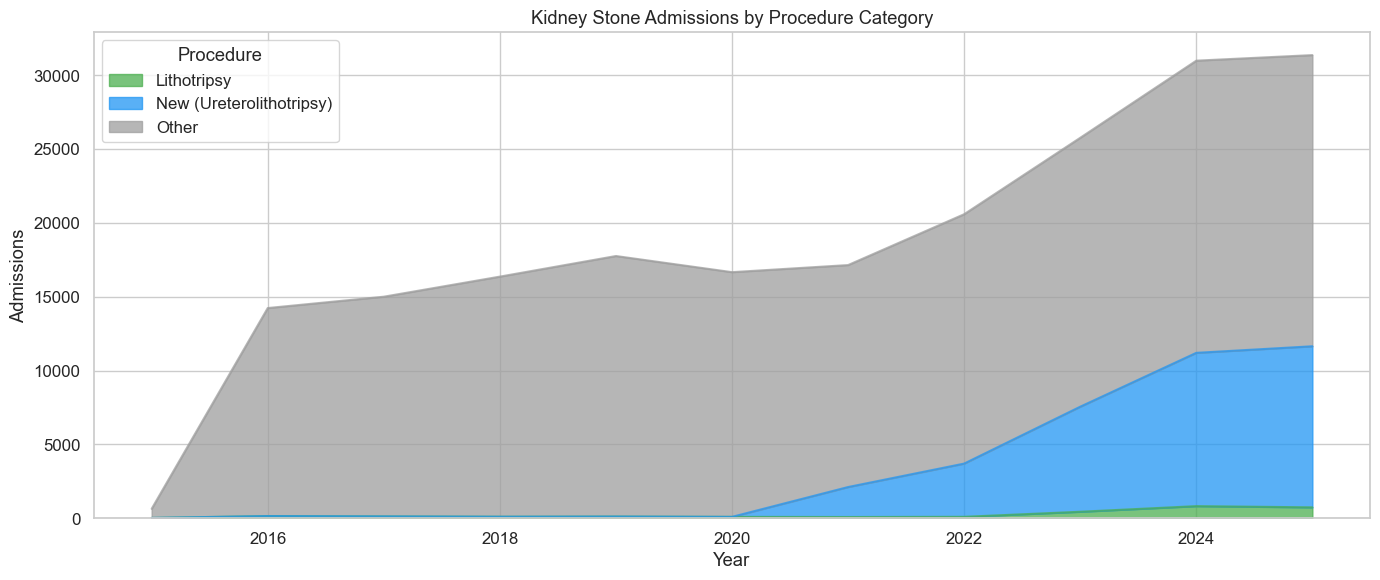

Total admission growth: 30,722
Growth from new procedure: 10,907 (35.5%)


In [2]:
NEW_PROC = "0409010596"  # Transureteroscopic Ureterolithotripsy
LITHO_PROC = "0409010146"  # Outpatient Lithotripsy

kidney["PROC_REA"] = kidney["PROC_REA"].astype(str).str.strip()
kidney["proc_category"] = np.where(
    kidney["PROC_REA"] == NEW_PROC, "New (Ureterolithotripsy)",
    np.where(kidney["PROC_REA"] == LITHO_PROC, "Lithotripsy", "Other")
)

proc_yearly = kidney.groupby(["year", "proc_category"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
proc_yearly.plot(kind="area", stacked=True, ax=ax, alpha=0.75,
                 color=["#4CAF50", "#2196F3", "#9E9E9E"])
ax.set_title("Kidney Stone Admissions by Procedure Category")
ax.set_xlabel("Year")
ax.set_ylabel("Admissions")
ax.legend(title="Procedure")

plt.tight_layout()
plt.savefig(PLOT_DIR / "03_procedure_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantify: what fraction of the growth is due to the new procedure?
first_year = proc_yearly.iloc[0].sum()
last_year = proc_yearly.iloc[-1]
total_growth = last_year.sum() - first_year
new_proc_growth = last_year.get("New (Ureterolithotripsy)", 0) - proc_yearly.iloc[0].get("New (Ureterolithotripsy)", 0)
pct_explained = new_proc_growth / total_growth * 100 if total_growth > 0 else 0

print(f"Total admission growth: {total_growth:,.0f}")
print(f"Growth from new procedure: {new_proc_growth:,.0f} ({pct_explained:.1f}%)")

## H2: Geographic Access Gap

Do patients in cities without the new procedure travel elsewhere for treatment?

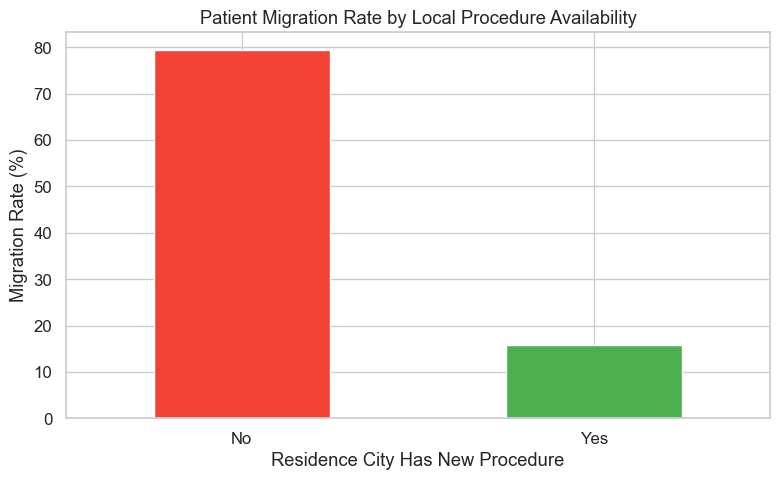

Migration rate — no local access: 79.4%
Migration rate — local access: 15.8%


In [3]:
kidney["MUNIC_RES"] = kidney["MUNIC_RES"].astype(str).str.strip()
kidney["MUNIC_MOV"] = kidney["MUNIC_MOV"].astype(str).str.strip()
kidney["migrated"] = kidney["MUNIC_RES"] != kidney["MUNIC_MOV"]

# Identify cities that perform the new procedure
adopter_cities = set(
    kidney.loc[kidney["PROC_REA"] == NEW_PROC, "MUNIC_MOV"].unique()
)
kidney["res_has_new_proc"] = kidney["MUNIC_RES"].isin(adopter_cities)

migration_by_access = kidney.groupby("res_has_new_proc")["migrated"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
migration_by_access.plot(kind="bar", ax=ax, color=["#F44336", "#4CAF50"])
ax.set_title("Patient Migration Rate by Local Procedure Availability")
ax.set_xlabel("Residence City Has New Procedure")
ax.set_ylabel("Migration Rate (%)")
ax.set_xticklabels(["No", "Yes"], rotation=0)

plt.tight_layout()
plt.savefig(PLOT_DIR / "03_access_gap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Migration rate — no local access: {migration_by_access[False]:.1f}%")
print(f"Migration rate — local access: {migration_by_access[True]:.1f}%")

## Procedure × Length of Stay

Average length of stay by procedure category:
                          mean  median   count
proc_category                                 
Lithotripsy               0.90     0.0    2784
New (Ureterolithotripsy)  1.86     1.0   34036
Other                     2.60     2.0  169680


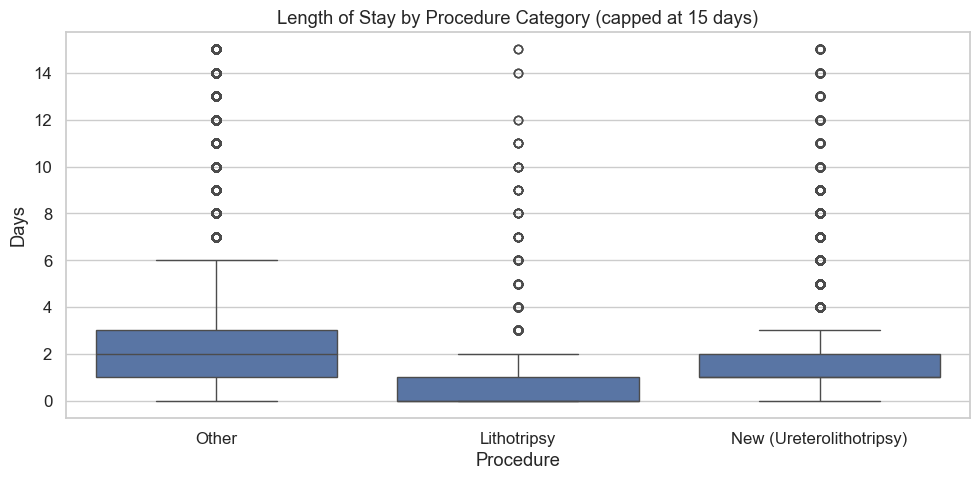

In [4]:
proc_stay = kidney.groupby("proc_category")["DIAS_PERM"].agg(["mean", "median", "count"])
print("Average length of stay by procedure category:")
print(proc_stay.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=kidney[kidney["DIAS_PERM"] <= 15], x="proc_category", y="DIAS_PERM", ax=ax)
ax.set_title("Length of Stay by Procedure Category (capped at 15 days)")
ax.set_xlabel("Procedure")
ax.set_ylabel("Days")

plt.tight_layout()
plt.savefig(PLOT_DIR / "03_procedure_stay.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Hypothesis Test Metrics

In [5]:
hypothesis_metrics = {
    "H1_procedure_decomposition": {
        "total_growth": int(total_growth),
        "new_proc_growth": int(new_proc_growth),
        "pct_explained_by_new_proc": round(pct_explained, 1),
    },
    "H2_access_gap": {
        "migration_rate_no_access": round(float(migration_by_access[False]), 1),
        "migration_rate_with_access": round(float(migration_by_access[True]), 1),
        "adopter_cities_count": len(adopter_cities),
    },
    "procedure_stay": proc_stay.to_dict(),
}

with open(METRICS_DIR / "hypothesis_tests.json", "w") as f:
    json.dump(hypothesis_metrics, f, indent=2, default=str)

print("Hypothesis testing complete.")
print(f"H1 verdict: New procedure explains {pct_explained:.0f}% of growth.")
print(f"H2 verdict: Migration rate {migration_by_access[False]:.0f}% without vs {migration_by_access[True]:.0f}% with access.")

Hypothesis testing complete.
H1 verdict: New procedure explains 36% of growth.
H2 verdict: Migration rate 79% without vs 16% with access.
